# Zero Gaussian Curvature Cone Section

### Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import trange
import k3d
import sys
import os
import time
import copy
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from models.model_architecture import GeneralNet
from training.optimizers import GaussNewton
from util.surface_sampling import sample_model_surface_binsearch, sample_model_surface_newton 
from util.error_metrics import chamfer_div, compute_distance 
from util.visualization.utils_mesh import get_mesh
from training.residuals import ResidualLibrary, ResidualTerm, compute_loss
from training.optimizers import GaussNewton


torch.manual_seed(0)


device = 'cpu' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

### True Surface

In [2]:
def sample_boundary(n_points=1200, dtype=torch.float64):
    third = n_points // 3
    t = torch.linspace(0, 2 * torch.pi, third, dtype=dtype)

    z1 = -torch.zeros_like(t)
    y1 = 1.0 * torch.cos(t)
    x1 = 1.0 * torch.sin(t)

    # Left loop in y-z plane (like helicoid end)
    z2 = torch.ones_like(t)
    y2 = 0.4 * torch.cos(t)
    x2 = 0.4 * torch.sin(t)

    loop1 = torch.vstack([x1, y1, z1])
    loop2 = torch.vstack([x2, y2, z2])
    return torch.cat([loop1, loop2], dim=1).T

pts_boundary = sample_boundary(n_points=1000)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()

Output()

### Pretraining

In [3]:
model = GeneralNet(ks=[3, 32, 32, 1])
model = model.double()
torch.compile(model)
# bind_model(model)
# Generate random training points
num_pretrain_samples = 10000
bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)
pts_pretrain = torch.rand(num_pretrain_samples, 3, dtype=torch.float64) * (bounds[:,1] - bounds[:,0]) + bounds[:,0]


def pretrain_loss(model, params, pts):
    inputs = pts.to(dtype=torch.float64)
    x, y = pts[:, 0], pts[:, 1]
    targets = x**2 + y**2 - 1
    preds = model(inputs).squeeze(1)
    return 0.5 * (preds - targets).square().mean()

# Pretraining loop
pretrain_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_pretrain_iters = 1000

for i in range(num_pretrain_iters):
    pretrain_optimizer.zero_grad()
    loss = pretrain_loss(model, model.params, pts_pretrain)
    loss.backward()
    pretrain_optimizer.step()
    
    if i % 100 == 0:
        print(f"Pretrain Iter {i}: Loss= {loss.item():.6f}")

print("Pretraining completed!")

verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-3, -3, -1.5], dtype=torch.float64),
    bbox_max=torch.tensor([3, 3, 1.5], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()


Pretrain Iter 0: Loss= 0.119938
Pretrain Iter 100: Loss= 0.072818
Pretrain Iter 200: Loss= 0.010990
Pretrain Iter 300: Loss= 0.002189
Pretrain Iter 400: Loss= 0.000861
Pretrain Iter 500: Loss= 0.000384
Pretrain Iter 600: Loss= 0.000202
Pretrain Iter 700: Loss= 0.000131
Pretrain Iter 800: Loss= 0.000099
Pretrain Iter 900: Loss= 0.000082
Pretraining completed!


/opt/homebrew/Caskroom/miniforge/base/envs/ginns/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

### Main training loop

In [4]:
res_lib = ResidualLibrary(model)

pts_eikonal = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
pts_eikonal = torch.cat((pts_eikonal, pts_boundary))

## Select the residual terms defining the specific problem
## (incl. weight, points, and (optional) target values)
res_terms = {
    "data":
        ResidualTerm(res_lib._data,           1.0,  pts_boundary, vals=0),
    "eikonal":
        ResidualTerm(res_lib._eikonal,        1e-3, pts_eikonal,        ),
    "gauss_curvature":
        ResidualTerm(res_lib._gauss_curvature, 1.0,  pts_boundary,       ),
}

  0%|          | 0/100000 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniforge/base/envs/ginns/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1741947704867/work/aten/src/ATen/native/TensorShape.cpp:3638.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


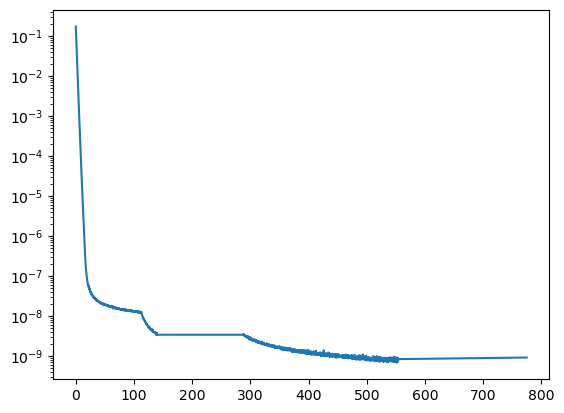

In [5]:
model = model.double()
params = model.params
loss_over_time = {}
best_loss = float('inf')

optim = GaussNewton(model, res_terms, lr=1e-1, regularization=1e-6, do_line_search=False)
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
start_time = time.time()
current_time = 0

for i in (pbar:=trange(100000)):
    # if current_time > 1200:
    if current_time > 600: # Shorter run for testing
        break
    optim.zero_grad()
    ## Update weights
    if i == 500:
        loss_weights = {"data": 1.0, "eikonal": 0.0, "gauss_curvature": 1.0}
        for key in res_terms:
            res_terms[key].weight = loss_weights[key]

    ## Update surface points
    bound_limit = 1.0
    bounds = torch.tensor([[-bound_limit,bound_limit], [-bound_limit,bound_limit], [-bound_limit,bound_limit]], dtype=torch.float64)
    pts_surface = sample_model_surface_binsearch(model, pts_boundary, bounds)
    res_terms["gauss_curvature"].points = pts_surface
    
    ## Evaluate the losses
    loss, unweighted_losses = compute_loss(params, res_terms, return_unweighted_losses=True)
        
    loss.backward()
    
    with torch.no_grad():
        loss_metric = unweighted_losses["data"] + unweighted_losses["gauss_curvature"]

        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric.item()
        if loss_metric.item() < best_loss:
            best_loss = loss_metric.item()
            best_model_state = copy.deepcopy(model.state_dict())

        unweighted_losses_str = " ".join(f"{key}: {l.item():.2e}" for key, l in unweighted_losses.items())
        pbar.set_description(unweighted_losses_str + " "
                            f"nof_pts: {len(pts_surface)}"
                            )
    optim.step()

# Optional: Load the best model after training
# if best_model_state is not None:
#     model.load_state_dict(best_model_state)
#     print(f"Best model loaded with loss {best_loss}")

plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

In [6]:
model = model.double()
params = model.params
loss_over_time = {}

optim = torch.optim.LBFGS(model.parameters(), lr=1e-1, max_iter=20, history_size=10)
start_time = time.time()
current_time = 0
best_loss = float('inf')
best_model_state = None

pbar = trange(100000)
for i in pbar:
    if current_time > 600:
        break

    # Update weights
    if i == 500:
        loss_weights = {"data": 1.0, "eikonal": 0.0, "gauss_curvature": 1.0}
        for key in res_terms:
            res_terms[key].weight = loss_weights[key]

    # Update surface points
    bound_limit = 1.0
    bounds = torch.tensor([[-bound_limit, bound_limit], [-bound_limit, bound_limit], [-bound_limit, bound_limit]], dtype=torch.float64)
    pts_surface = sample_model_surface_binsearch(model, pts_boundary, bounds)
    res_terms["gauss_curvature"].points = pts_surface

    def closure():
        optim.zero_grad()
        loss, _ = compute_loss(params, res_terms, return_unweighted_losses=True)
        loss.backward()
        return loss

    loss, unweighted_losses = compute_loss(params, res_terms, return_unweighted_losses=True)
    optim.step(closure)

    with torch.no_grad():
        loss_metric = unweighted_losses["data"] + unweighted_losses["gauss_curvature"]
        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric.item()

        if loss_metric.item() < best_loss:
            best_loss = loss_metric.item()
            best_model_state = copy.deepcopy(model.state_dict())

        unweighted_losses_str = " ".join(f"{key}: {l.item():.2e}" for key, l in unweighted_losses.items())
        pbar.set_description(unweighted_losses_str + " "
                            f"nof_pts: {len(pts_surface)}"
                            )

# Optional: Load the best model after training
# if best_model_state is not None:
#     model.load_state_dict(best_model_state)
#     print(f"Best model loaded with loss {best_loss}")

plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

  0%|          | 0/100000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [7]:
# # Optional: Load the best model after training
# if best_model_state is not None:
#     model.load_state_dict(best_model_state)
#     print(f"Best model loaded with loss {best_loss}")

In [8]:
# torch.save(model.state_dict(), '3,32,32,1,tanh,cone,adam')

In [9]:
# os.makedirs("Data Cone", exist_ok=True)

# loss_file = os.path.join("Data Cone", "loss_over_time_cone_adam.pth")

# torch.save(loss_over_time, loss_file)
# print(f"Loss saved to {loss_file}")

### Visualize the result

In [10]:
# model.load_state_dict(torch.load('Trained Models/3,32,32,1,tanh,cone,gn'))

In [6]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1.2, -1.2, -0.05], dtype=torch.float64),
    bbox_max=torch.tensor([1.2, 1.2, 1.05], dtype=torch.float64),
    chunks=2
)


fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.02)
fig.display()

Output()

In [7]:
verts, faces = get_mesh(
    model.float(), N=256, device=device,
    bbox_min=torch.tensor([-2, -2, -0.05], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 1.05], dtype=torch.float64),
    chunks=2
)

model.double()
from torch.func import vmap

# Vectorized gauss curvature calculation
mean_curvatures = vmap(res_lib._gauss_curvature, in_dims=(None, 0))(
    model.params, torch.tensor(verts, dtype=torch.float64)
).squeeze()

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)

color_map = k3d.basic_color_maps.Jet
color_range = [0, 0.005]

fig += k3d.mesh(
    verts, faces, 
    attribute=mean_curvatures.cpu().detach().numpy().astype(np.float32),
    color_range=color_range,
    color_map=color_map,
    side='double',
    flat_shading=False
)

fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()

Output()

In [13]:
# fig_output_file = "../docs/k3d_plot_cone_gn.html"
# with open(fig_output_file, 'w') as f:
#     f.write(fig.get_snapshot())
# print(f"Plot saved to {fig_output_file}")